In [ ]:
import pandas as pd
import numpy as np

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    log_loss,
    confusion_matrix,
    classification_report
)

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

Load the feature dataset

In [ ]:
df = pd.read_csv("monopoly_features.csv")

print(df.shape)
df.head()

(48796, 38)


,result_lag_1,result_lag_2,result_lag_3,result_lag_4,result_lag_5,multiplier_lag_1,multiplier_lag_2,multiplier_lag_3,multiplier_lag_4,multiplier_lag_5,...,result_5_count_20,result_10_count_10,result_10_count_20,result_20_count_10,result_20_count_20,result_40_count_10,result_40_count_20,result_50_count_10,result_50_count_20,target
0,1.0,1.0,10.0,1.0,2.0,1.0,1.0,10.0,1.0,2.0,...,2.0,3.0,4.0,1.0,1.0,0.0,0.0,0.0,0.0,2
1,2.0,1.0,1.0,10.0,1.0,2.0,1.0,1.0,10.0,1.0,...,2.0,3.0,3.0,0.0,1.0,0.0,0.0,0.0,0.0,1
2,1.0,2.0,1.0,1.0,10.0,1.0,2.0,1.0,1.0,10.0,...,2.0,2.0,3.0,0.0,1.0,0.0,0.0,0.0,0.0,2
3,2.0,1.0,2.0,1.0,1.0,2.0,1.0,2.0,1.0,1.0,...,2.0,1.0,3.0,0.0,1.0,0.0,0.0,0.0,0.0,1
4,1.0,2.0,1.0,2.0,1.0,1.0,2.0,1.0,2.0,1.0,...,1.0,1.0,3.0,0.0,1.0,0.0,0.0,0.0,0.0,2


In [ ]:
df = df.dropna(subset=['target'])
X = df.drop(columns=["target"])
y = df["target"]

In [ ]:
print("Features:", X.shape)
print("Target:", y.shape)

Features: (48796, 37)
Target: (48796,)


Do not use train_test_split() randomly here.

Because this is sequential data, we want: train 70% val 15% test 15%

In [ ]:
n = len(df)

train_end = int(n * 0.70)
validation_end = int(n * 0.85)

X_train = X.iloc[:train_end]
y_train = y.iloc[:train_end]

X_val = X.iloc[train_end:validation_end]
y_val = y.iloc[train_end:validation_end]

X_test = X.iloc[validation_end:]
y_test = y.iloc[validation_end:]

print("Training:", X_train.shape)
print("Validation:", X_val.shape)
print("Testing:", X_test.shape)

Training: (34157, 37)
Validation: (7319, 37)
Testing: (7320, 37)


In [ ]:
# First model

baseline_prediction = 1

baseline_accuracy = accuracy_score(
    y_test,
    [baseline_prediction] * len(y_test)
)

print(
    f"Baseline accuracy: {baseline_accuracy:.4f}"
)

Baseline accuracy: 0.4068


In [ ]:
# Logistic regression
logistic_model = Pipeline([
    (
        "scaler",
        StandardScaler()
    ),
    (
        "model",
        LogisticRegression(
            max_iter=2000,
            class_weight="balanced"
        )
    )
])

logistic_model.fit(
    X_train,
    y_train
)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=2000))])

In [ ]:
logistic_pred = logistic_model.predict(X_test)

logistic_proba = (
    logistic_model.predict_proba(X_test)
)

In [ ]:
print(
    "Accuracy:",
    accuracy_score(y_test, logistic_pred)
)

print(
    "Balanced Accuracy:",
    balanced_accuracy_score(
        y_test,
        logistic_pred
    )
)

print(
    "Macro F1:",
    f1_score(
        y_test,
        logistic_pred,
        average="macro"
    )
)

print(
    "Log Loss:",
    log_loss(
        y_test,
        logistic_proba
    )
)

Accuracy: 0.0633879781420765
Balanced Accuracy: 0.1376312559295245
Macro F1: 0.06463919622414924
Log Loss: 1.9452419828047047


In [ ]:
# Random Forest

rf_model = RandomForestClassifier(
    n_estimators=300,
    min_samples_leaf=5,
    class_weight="balanced_subsample",
    n_jobs=-1,
    random_state=42
)

rf_model.fit(
    X_train,
    y_train
)

RandomForestClassifier(class_weight='balanced_subsample', min_samples_leaf=5,
                       n_estimators=300, n_jobs=-1, random_state=42)

In [ ]:
rf_pred = rf_model.predict(X_test)

rf_proba = rf_model.predict_proba(X_test)

In [ ]:
print(
    "Accuracy:",
    accuracy_score(y_test, rf_pred)
)

print(
    "Balanced Accuracy:",
    balanced_accuracy_score(
        y_test,
        rf_pred
    )
)

print(
    "Macro F1:",
    f1_score(
        y_test,
        rf_pred,
        average="macro"
    )
)

print(
    "Log Loss:",
    log_loss(
        y_test,
        rf_proba
    )
)

Accuracy: 0.3637978142076503
Balanced Accuracy: 0.14367276654193567
Macro F1: 0.12438661887004736
Log Loss: 1.638039329844648


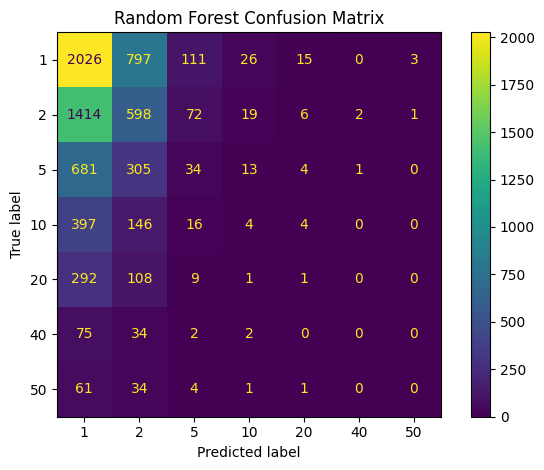

In [ ]:
#confusion matrix

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    rf_pred
)

plt.title("Random Forest Confusion Matrix")
plt.tight_layout()
plt.show()

In [ ]:
print(
    classification_report(
        y_test,
        rf_pred,
        zero_division=0
    )
)

              precision    recall  f1-score   support

           1       0.41      0.68      0.51      2978
           2       0.30      0.28      0.29      2112
           5       0.14      0.03      0.05      1038
          10       0.06      0.01      0.01       567
          20       0.03      0.00      0.00       411
          40       0.00      0.00      0.00       113
          50       0.00      0.00      0.00       101

    accuracy                           0.36      7320
   macro avg       0.13      0.14      0.12      7320
weighted avg       0.28      0.36      0.30      7320



Feature importance

In [ ]:
importance = pd.Series(
    rf_model.feature_importances_,
    index=X_train.columns
)

importance = importance.sort_values(
    ascending=False
)

print(importance.head(20))

multiplier_std_20     0.066346
minute                0.064271
multiplier_mean_20    0.058655
multiplier_std_10     0.058518
multiplier_mean_10    0.052133
multiplier_std_5      0.045585
multiplier_mean_5     0.043350
hour                  0.041772
hour_cos              0.037800
hour_sin              0.037071
day_of_week           0.033066
result_1_count_20     0.032267
result_2_count_20     0.032117
result_5_count_20     0.027495
result_1_count_10     0.023758
result_2_count_10     0.023589
multiplier_lag_2      0.021750
multiplier_lag_5      0.021215
result_10_count_20    0.021045
multiplier_lag_1      0.020765
dtype: float64


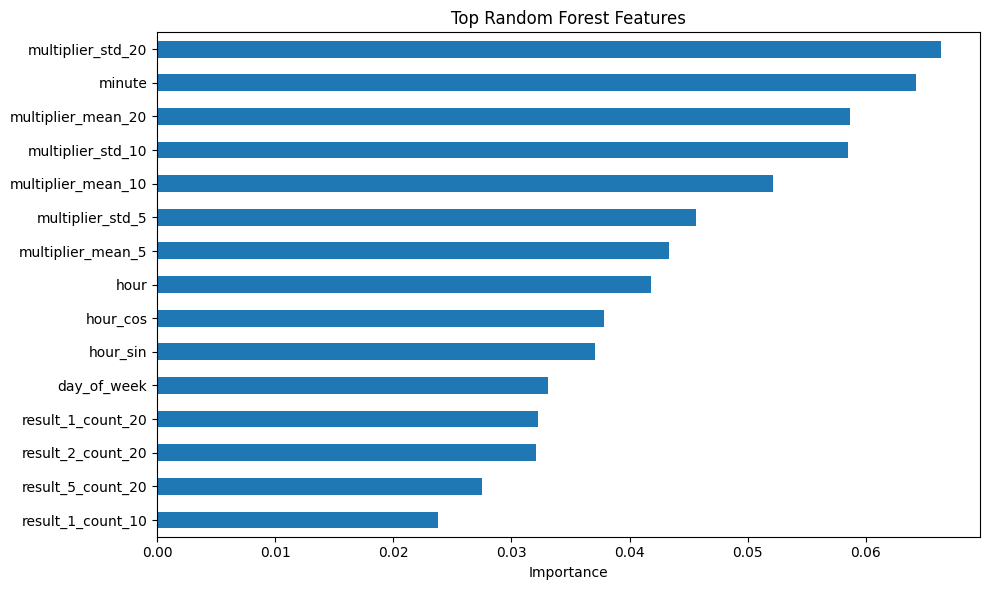

In [ ]:
#visualize
importance.head(15).sort_values().plot(
    kind="barh",
    figsize=(10, 6)
)

plt.title("Top Random Forest Features")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

In [ ]:
transition = pd.crosstab(
    df["result_lag_1"],
    df["target"],
    normalize="index"
)

print(
    transition.round(3)
)

target           1      2      5      10     20     40     50
result_lag_1                                                 
1.0           0.419  0.287  0.135  0.076  0.054  0.016  0.013
2.0           0.418  0.286  0.132  0.075  0.057  0.019  0.013
5.0           0.420  0.282  0.129  0.075  0.059  0.019  0.016
10.0          0.402  0.288  0.142  0.074  0.061  0.019  0.014
20.0          0.394  0.293  0.141  0.086  0.054  0.018  0.014
40.0          0.384  0.301  0.147  0.079  0.049  0.026  0.014
50.0          0.441  0.279  0.127  0.062  0.068  0.014  0.009


Historical round-level features did not provide sufficient predictive signal to reliably outperform the dominant-class baseline on unseen data.

In [ ]:
#Let's investigate streaks
df["same_as_previous"] = (
    df["target"] ==
    df["target"].shift(1)
)

df["streak_id"] = (
    df["same_as_previous"] == False
).cumsum()

df["streak_length"] = (
    df.groupby("streak_id")
    .cumcount() + 1
)

In [ ]:
print(
    df["streak_length"]
    .value_counts()
    .sort_index()
    .head(15)
)

streak_length
1     34991
2      9015
3      2974
4      1139
5       447
6       154
7        51
8        17
9         6
10        1
11        1
Name: count, dtype: int64


In [ ]:
print(
    "Longest streak:",
    df["streak_length"].max()
)

Longest streak: 11


In [ ]:
#Test what happens after a streak

streak_2 = df[
    df["streak_length"] >= 2
]

print(
    streak_2["target"].value_counts(
        normalize=True
    ).sort_index().round(3)
)

target
1     0.617
2     0.289
5     0.061
10    0.020
20    0.011
40    0.002
50    0.000
Name: proportion, dtype: float64


In [ ]:
print(
    df["target"].value_counts(
        normalize=True
    ).sort_index().round(3)
)

target
1     0.416
2     0.286
5     0.134
10    0.076
20    0.056
40    0.017
50    0.014
Name: proportion, dtype: float64


In [ ]:
#Now investigate feature importance

importance = pd.Series(
    rf_model.feature_importances_,
    index=X_train.columns
)

importance = importance.sort_values(
    ascending=False
)

print(
    importance.head(20)
)

multiplier_std_20     0.066346
minute                0.064271
multiplier_mean_20    0.058655
multiplier_std_10     0.058518
multiplier_mean_10    0.052133
multiplier_std_5      0.045585
multiplier_mean_5     0.043350
hour                  0.041772
hour_cos              0.037800
hour_sin              0.037071
day_of_week           0.033066
result_1_count_20     0.032267
result_2_count_20     0.032117
result_5_count_20     0.027495
result_1_count_10     0.023758
result_2_count_10     0.023589
multiplier_lag_2      0.021750
multiplier_lag_5      0.021215
result_10_count_20    0.021045
multiplier_lag_1      0.020765
dtype: float64


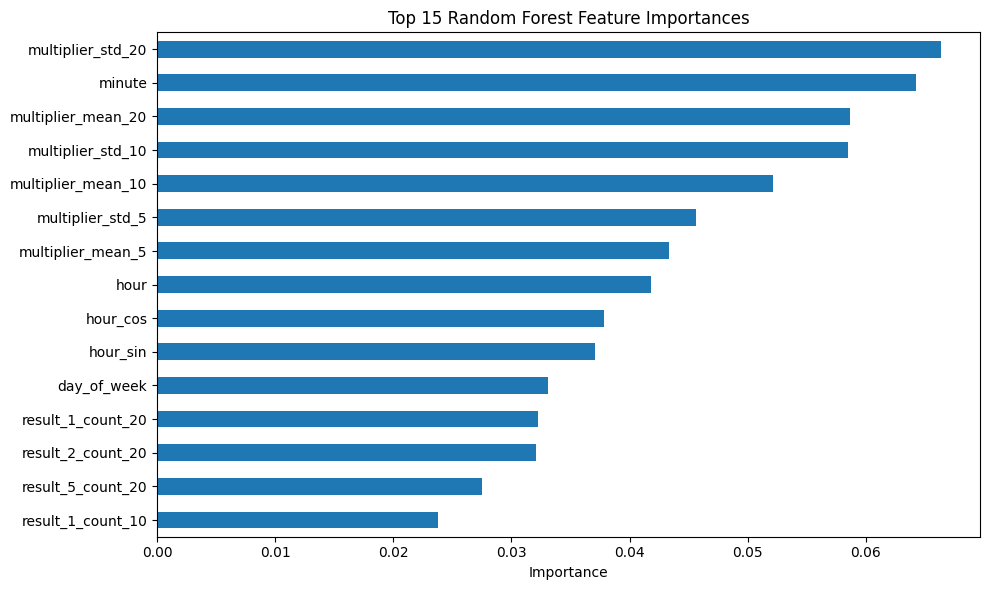

In [ ]:
import matplotlib.pyplot as plt

importance.head(15).sort_values().plot(
    kind="barh",
    figsize=(10, 6)
)

plt.title(
    "Top 15 Random Forest Feature Importances"
)

plt.xlabel("Importance")
plt.tight_layout()
plt.show()

In [ ]:
# Check the models actual prediction

prediction_distribution = pd.Series(
    rf_pred
).value_counts(
    normalize=True
).sort_index()

print(
    prediction_distribution.round(3)
)

1     0.676
2     0.276
5     0.034
10    0.009
20    0.004
40    0.000
50    0.001
Name: proportion, dtype: float64


In [ ]:
#comparing

print("Actual:")
print(
    y_test.value_counts(
        normalize=True
    ).sort_index().round(3)
)

print("\nPredicted:")
print(
    prediction_distribution.round(3)
)

Actual:
target
1     0.407
2     0.289
5     0.142
10    0.077
20    0.056
40    0.015
50    0.014
Name: proportion, dtype: float64

Predicted:
1     0.676
2     0.276
5     0.034
10    0.009
20    0.004
40    0.000
50    0.001
Name: proportion, dtype: float64


Calculating a better baseline

In [ ]:
# Instead of only comparing against:Always predict 1.we can build a probability baseline using the historical class frequencies.

from sklearn.metrics import log_loss

class_labels = sorted(y_train.unique())

train_probabilities = (
    y_train.value_counts(normalize=True)
    .reindex(class_labels)
    .fillna(0)
    .values
)

baseline_probabilities = np.tile(
    train_probabilities,
    (len(y_test), 1)
)

print(
    "Baseline Log Loss:",
    log_loss(
        y_test,
        baseline_probabilities,
        labels=class_labels
    )
)

Baseline Log Loss: 1.485319406257811


Test whether historical sequence contains predictive signal

In [ ]:
!pip install xgboost
from xgboost import XGBClassifier

#train xgboost
classes = sorted(y_train.unique())

class_to_int = {
    value: i
    for i, value in enumerate(classes)
}

int_to_class = {
    i: value
    for value, i in class_to_int.items()
}

y_train_encoded = y_train.map(class_to_int)
y_test_encoded = y_test.map(class_to_int)

xgb_model = XGBClassifier(
    n_estimators=400,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softprob",
    num_class=len(classes),
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=4
)

xgb_model.fit(
    X_train,
    y_train_encoded
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=400, n_jobs=4, num_class=7, ...)

In [ ]:
#predict
xgb_pred_encoded = xgb_model.predict(X_test)

xgb_pred = np.array([
    int_to_class[int(x)]
    for x in xgb_pred_encoded
])

xgb_proba = xgb_model.predict_proba(X_test)

In [ ]:
#evaluate

print(
    "Accuracy:",
    accuracy_score(y_test, xgb_pred)
)

print(
    "Balanced Accuracy:",
    balanced_accuracy_score(
        y_test,
        xgb_pred
    )
)

print(
    "Macro F1:",
    f1_score(
        y_test,
        xgb_pred,
        average="macro"
    )
)

print(
    "Log Loss:",
    log_loss(
        y_test,
        xgb_proba,
        labels=classes
    )
)

Accuracy: 0.39795081967213114
Balanced Accuracy: 0.14180893942163325
Macro F1: 0.0922896869538113
Log Loss: 1.5025259215402176


Shuffled history experiment

In [ ]:
# let's deliberately destroy the relationship between the historical features and the target.

rng = np.random.default_rng(42)

X_train_shuffled = X_train.copy()
X_test_shuffled = X_test.copy()

for column in X.columns:

    X_train_shuffled[column] = rng.permutation(
        X_train_shuffled[column].values
    )

    X_test_shuffled[column] = rng.permutation(
        X_test_shuffled[column].values
    )

In [ ]:
#training another random forest

rf_shuffled = RandomForestClassifier(
    n_estimators=300,
    min_samples_leaf=5,
    class_weight="balanced_subsample",
    n_jobs=-1,
    random_state=42
)

rf_shuffled.fit(
    X_train_shuffled,
    y_train
)

RandomForestClassifier(class_weight='balanced_subsample', min_samples_leaf=5,
                       n_estimators=300, n_jobs=-1, random_state=42)

In [ ]:
#predict
shuffled_pred = rf_shuffled.predict(
    X_test_shuffled
)

shuffled_proba = rf_shuffled.predict_proba(
    X_test_shuffled
)

In [ ]:
#evaluate
print(
    "Accuracy:",
    accuracy_score(
        y_test,
        shuffled_pred
    )
)

print(
    "Balanced Accuracy:",
    balanced_accuracy_score(
        y_test,
        shuffled_pred
    )
)

print(
    "Macro F1:",
    f1_score(
        y_test,
        shuffled_pred,
        average="macro"
    )
)

print(
    "Log Loss:",
    log_loss(
        y_test,
        shuffled_proba,
        labels=classes
    )
)

Accuracy: 0.37937158469945353
Balanced Accuracy: 0.14213001978769582
Macro F1: 0.11161602873308092
Log Loss: 1.6098735090736351


The shuffled model is surprisingly close to the real-history models.

That tells us we should not claim that the historical sequence is predictive.

# Binary prediction

In [ ]:
#Create binary target

# High-value outcomes
high_results = [10, 20, 40, 50]

df["target_binary"] = (
    df["target"].isin(high_results)
).astype(int)

print(
    df["target_binary"].value_counts()
)

print(
    df["target_binary"]
    .value_counts(normalize=True)
)

target_binary
0    40839
1     7957
Name: count, dtype: int64
target_binary
0    0.836933
1    0.163067
Name: proportion, dtype: float64


In [ ]:
#separate features and targets

X = df.drop(
    columns=["target", "target_binary"]
)

y = df["target_binary"]

In [ ]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (48796, 40)
y shape: (48796,)


In [ ]:
#Chronological split
n = len(df)

train_end = int(n * 0.70)
validation_end = int(n * 0.85)

X_train = X.iloc[:train_end]
y_train = y.iloc[:train_end]

X_val = X.iloc[train_end:validation_end]
y_val = y.iloc[train_end:validation_end]

X_test = X.iloc[validation_end:]
y_test = y.iloc[validation_end:]

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (34157, 40)
Validation: (7319, 40)
Test: (7320, 40)


Establish the binary baseline

In [ ]:
high_probability = y_train.mean()

print(
    f"High-result probability: "
    f"{high_probability:.4f}"
)

High-result probability: 0.1636


For a classification baseline, predicting the majority class:

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

baseline_pred = np.zeros(
    len(y_test),
    dtype=int
)

print(
    "Baseline Accuracy:",
    accuracy_score(y_test, baseline_pred)
)

print(
    "Baseline Balanced Accuracy:",
    balanced_accuracy_score(
        y_test,
        baseline_pred
    )
)

Baseline Accuracy: 0.8371584699453551
Baseline Balanced Accuracy: 0.5


#Logistic regression

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

logistic = Pipeline([
    (
        "scaler",
        StandardScaler()
    ),
    (
        "model",
        LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            random_state=42
        )
    )
])

logistic.fit(
    X_train,
    y_train
)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=2000,
                                    random_state=42))])

In [ ]:
logistic_proba = logistic.predict_proba(
    X_test
)[:, 1]

logistic_pred = (
    logistic_proba >= 0.5
).astype(int)

In [ ]:
print(
    "Accuracy:",
    accuracy_score(
        y_test,
        logistic_pred
    )
)

print(
    "Balanced Accuracy:",
    balanced_accuracy_score(
        y_test,
        logistic_pred
    )
)

print(
    "F1:",
    f1_score(
        y_test,
        logistic_pred
    )
)

print(
    "ROC-AUC:",
    roc_auc_score(
        y_test,
        logistic_proba
    )
)

print(
    "PR-AUC:",
    average_precision_score(
        y_test,
        logistic_proba
    )
)

Accuracy: 0.42308743169398905
Balanced Accuracy: 0.63076953405646
F1: 0.34638600835783934
ROC-AUC: 0.6540554852191284
PR-AUC: 0.23139480129743029


# Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=400,
    min_samples_leaf=5,
    class_weight="balanced_subsample",
    n_jobs=-1,
    random_state=42
)

rf.fit(
    X_train,
    y_train
)

RandomForestClassifier(class_weight='balanced_subsample', min_samples_leaf=5,
                       n_estimators=400, n_jobs=-1, random_state=42)

In [ ]:
rf_proba = rf.predict_proba(
    X_test
)[:, 1]

rf_pred = (
    rf_proba >= 0.5
).astype(int)

In [ ]:
print(
    "Accuracy:",
    accuracy_score(
        y_test,
        rf_pred
    )
)

print(
    "Balanced Accuracy:",
    balanced_accuracy_score(
        y_test,
        rf_pred
    )
)

print(
    "F1:",
    f1_score(
        y_test,
        rf_pred
    )
)

print(
    "ROC-AUC:",
    roc_auc_score(
        y_test,
        rf_proba
    )
)

print(
    "PR-AUC:",
    average_precision_score(
        y_test,
        rf_proba
    )
)

Accuracy: 0.8323770491803278
Balanced Accuracy: 0.534647870047488
F1: 0.15320910973084886
ROC-AUC: 0.7187884690363958
PR-AUC: 0.32425227040241267


XGBOOST

In [ ]:
!pip install xgboostfrom xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=400,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42,
    n_jobs=4
)

xgb.fit(
    X_train,
    y_train
)

ERROR: Could not find a version that satisfies the requirement xgboostfrom (from versions: none)
ERROR: No matching distribution found for xgboostfrom


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=400, n_jobs=4,
              num_parallel_tree=None, ...)

In [ ]:
xgb_proba = xgb.predict_proba(
    X_test
)[:, 1]

xgb_pred = (
    xgb_proba >= 0.5
).astype(int)

In [ ]:
print(
    "Accuracy:",
    accuracy_score(
        y_test,
        xgb_pred
    )
)

print(
    "Balanced Accuracy:",
    balanced_accuracy_score(
        y_test,
        xgb_pred
    )
)

print(
    "F1:",
    f1_score(
        y_test,
        xgb_pred
    )
)

print(
    "ROC-AUC:",
    roc_auc_score(
        y_test,
        xgb_proba
    )
)

print(
    "PR-AUC:",
    average_precision_score(
        y_test,
        xgb_proba
    )
)

Accuracy: 0.8418032786885246
Balanced Accuracy: 0.5311552648641071
F1: 0.12669683257918551
ROC-AUC: 0.7164010614716035
PR-AUC: 0.32196488134054985


Create a model comparison table

In [ ]:
results = []

models = {
    "Logistic Regression": (
        logistic_pred,
        logistic_proba
    ),
    "Random Forest": (
        rf_pred,
        rf_proba
    ),
    "XGBoost": (
        xgb_pred,
        xgb_proba
    )
}

for name, (pred, proba) in models.items():

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(
            y_test,
            pred
        ),
        "Balanced Accuracy":
            balanced_accuracy_score(
                y_test,
                pred
            ),
        "F1": f1_score(
            y_test,
            pred
        ),
        "ROC-AUC": roc_auc_score(
            y_test,
            proba
        ),
        "PR-AUC": average_precision_score(
            y_test,
            proba
        )
    })

results_df = pd.DataFrame(results)

print(
    results_df.round(4)
)

                 Model  Accuracy  Balanced Accuracy      F1  ROC-AUC  PR-AUC
0  Logistic Regression    0.4231             0.6308  0.3464   0.6541  0.2314
1        Random Forest    0.8324             0.5346  0.1532   0.7188  0.3243
2              XGBoost    0.8418             0.5312  0.1267   0.7164  0.3220


Plot ROC curve

<Figure size 800x600 with 0 Axes>

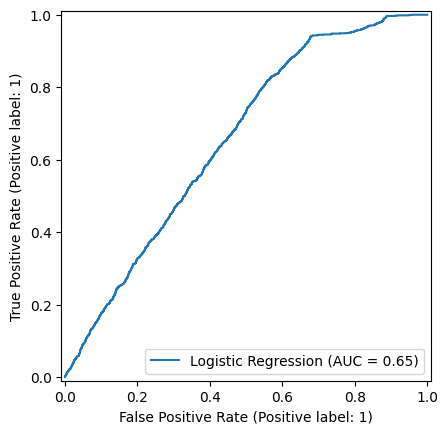

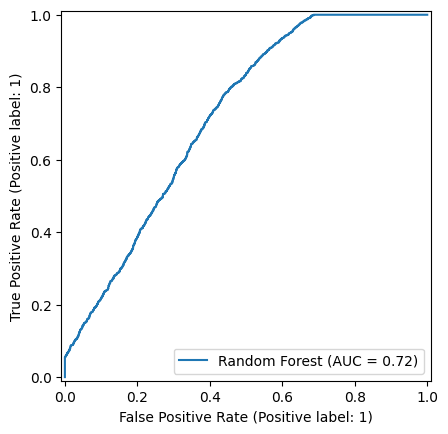

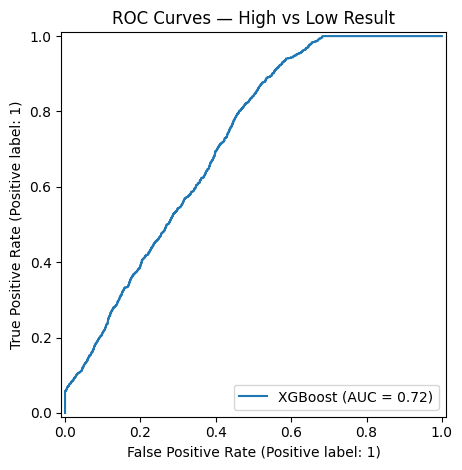

In [ ]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

RocCurveDisplay.from_predictions(
    y_test,
    logistic_proba,
    name="Logistic Regression"
)

RocCurveDisplay.from_predictions(
    y_test,
    rf_proba,
    name="Random Forest"
)

RocCurveDisplay.from_predictions(
    y_test,
    xgb_proba,
    name="XGBoost"
)

plt.title(
    "ROC Curves — High vs Low Result"
)

plt.tight_layout()
plt.show()

Precision Recall curve

<Figure size 800x600 with 0 Axes>

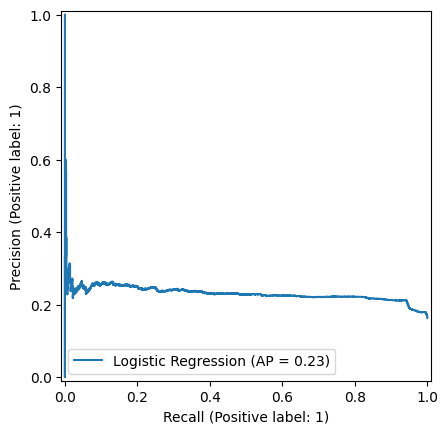

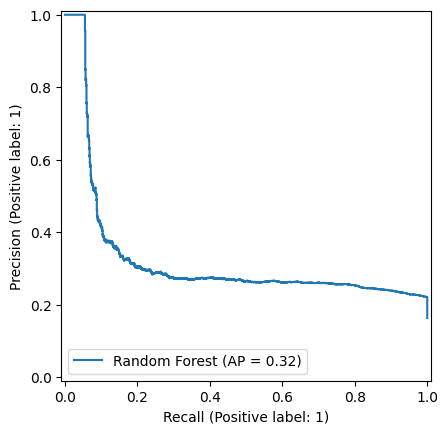

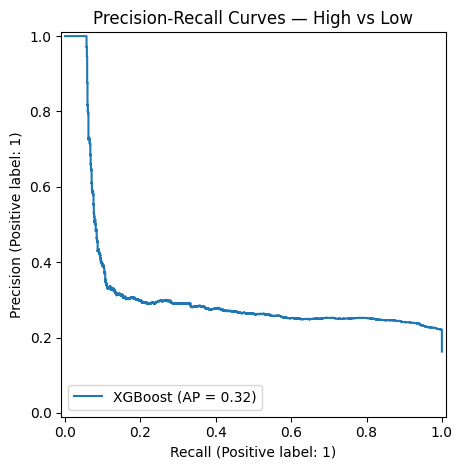

In [ ]:
from sklearn.metrics import PrecisionRecallDisplay

plt.figure(figsize=(8, 6))

PrecisionRecallDisplay.from_predictions(
    y_test,
    logistic_proba,
    name="Logistic Regression"
)

PrecisionRecallDisplay.from_predictions(
    y_test,
    rf_proba,
    name="Random Forest"
)

PrecisionRecallDisplay.from_predictions(
    y_test,
    xgb_proba,
    name="XGBoost"
)

plt.title(
    "Precision-Recall Curves — High vs Low"
)

plt.tight_layout()
plt.show()

Confusion matrix

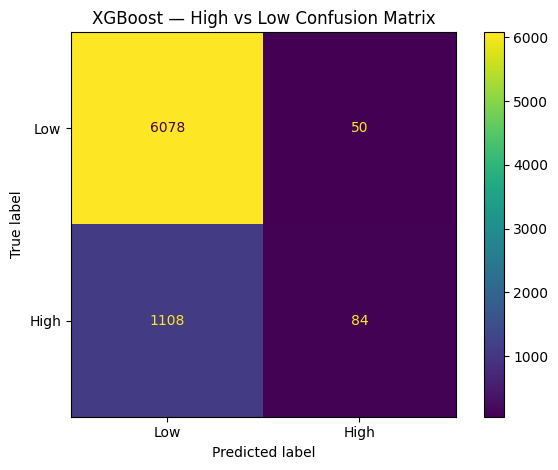

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    xgb_pred,
    display_labels=[
        "Low",
        "High"
    ]
)

plt.title(
    "XGBoost — High vs Low Confusion Matrix"
)

plt.tight_layout()
plt.show()

In [ ]:
print(
    classification_report(
        y_test,
        xgb_pred,
        target_names=[
            "Low",
            "High"
        ],
        zero_division=0
)
)

              precision    recall  f1-score   support

         Low       0.85      0.99      0.91      6128
        High       0.63      0.07      0.13      1192

    accuracy                           0.84      7320
   macro avg       0.74      0.53      0.52      7320
weighted avg       0.81      0.84      0.78      7320



The most important test: does it beat a shuffled dataset?

In [ ]:
rng = np.random.default_rng(42)

X_train_shuffled = X_train.copy()
X_test_shuffled = X_test.copy()

for column in X.columns:

    X_train_shuffled[column] = rng.permutation(
        X_train_shuffled[column].values
    )

    X_test_shuffled[column] = rng.permutation(
        X_test_shuffled[column].values
    )

In [ ]:
#train

xgb_shuffled = XGBClassifier(
    n_estimators=400,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42,
    n_jobs=4
)

xgb_shuffled.fit(
    X_train_shuffled,
    y_train
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=400, n_jobs=4,
              num_parallel_tree=None, ...)

In [ ]:
#evaluate
shuffled_proba = (
    xgb_shuffled
    .predict_proba(X_test_shuffled)[:, 1]
)

print(
    "Shuffled ROC-AUC:",
    roc_auc_score(
        y_test,
        shuffled_proba
    )
)

print(
    "Shuffled PR-AUC:",
    average_precision_score(
        y_test,
        shuffled_proba
    )
)

Shuffled ROC-AUC: 0.5065936065282913
Shuffled PR-AUC: 0.16790593430393982


# Hyperparameter Tuning

In [ ]:
#Random Forest

from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.ensemble import RandomForestClassifier

# Time-series cross validation
tscv = TimeSeriesSplit(n_splits=5)

# Random Forest
rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

# Hyperparameter search space
rf_param_grid = {
    "n_estimators": [100,200, 300, 500],
    "max_depth": [None, 5, 10, 15, 20, 30],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 5, 10],
    "max_features": ["sqrt", "log2", None],
    "class_weight": [None, "balanced", "balanced_subsample"]
}

rf_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=rf_param_grid,
    n_iter=30,
    scoring="roc_auc",
    cv=tscv,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

rf_search.fit(X_train, y_train)

print("Best Random Forest parameters:")
print(rf_search.best_params_)

print("\nBest CV ROC-AUC:")
print(rf_search.best_score_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best Random Forest parameters:
{'n_estimators': 300, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': None, 'max_depth': 5, 'class_weight': None}

Best CV ROC-AUC:
0.7383269569541963


In [ ]:
#Evaluate the tuned random forest

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

best_rf = rf_search.best_estimator_

rf_pred = best_rf.predict(X_test)
rf_proba = best_rf.predict_proba(X_test)[:, 1]

print("Tuned Random Forest Results")
print("---------------------------")

print("Accuracy:",
      accuracy_score(y_test, rf_pred))

print("Balanced Accuracy:",
      balanced_accuracy_score(y_test, rf_pred))

print("F1 Score:",
      f1_score(y_test, rf_pred))

print("ROC-AUC:",
      roc_auc_score(y_test, rf_proba))

print("PR-AUC:",
      average_precision_score(y_test, rf_proba))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, rf_pred))

print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

Tuned Random Forest Results
---------------------------
Accuracy: 0.846448087431694
Balanced Accuracy: 0.5285234899328859
F1 Score: 0.10793650793650794
ROC-AUC: 0.7310164888420629
PR-AUC: 0.3360674358565708

Confusion Matrix:
[[6128    0]
 [1124   68]]

Classification Report:
              precision    recall  f1-score   support

           0       0.85      1.00      0.92      6128
           1       1.00      0.06      0.11      1192

    accuracy                           0.85      7320
   macro avg       0.92      0.53      0.51      7320
weighted avg       0.87      0.85      0.78      7320



tune XGBOOST

In [ ]:
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit

xgb = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

xgb_param_grid = {
    "n_estimators": [100, 200, 300, 400, 500],
    "max_depth": [2, 3, 4, 5, 6, 8],
    "learning_rate": [0.01, 0.03, 0.05, 0.1, 0.2],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "min_child_weight": [1, 3, 5, 10],
    "gamma": [0, 0.1, 0.3, 0.5],
    "reg_alpha": [0, 0.01, 0.1, 1],
    "reg_lambda": [1, 1.5, 2, 5]
}

xgb_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=xgb_param_grid,
    n_iter=30,
    scoring="roc_auc",
    cv=tscv,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

xgb_search.fit(X_train, y_train)

print("Best XGBoost parameters:")
print(xgb_search.best_params_)

print("\nBest CV ROC-AUC:")
print(xgb_search.best_score_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best XGBoost parameters:
{'subsample': 1.0, 'reg_lambda': 2, 'reg_alpha': 1, 'n_estimators': 100, 'min_child_weight': 3, 'max_depth': 3, 'learning_rate': 0.03, 'gamma': 0.3, 'colsample_bytree': 0.7}

Best CV ROC-AUC:
0.7417423795098469


In [ ]:
#evaluate tuned xgboost

best_xgb = xgb_search.best_estimator_

xgb_pred = best_xgb.predict(X_test)
xgb_proba = best_xgb.predict_proba(X_test)[:, 1]

print("Tuned XGBoost Results")
print("---------------------")

print("Accuracy:",
      accuracy_score(y_test, xgb_pred))

print("Balanced Accuracy:",
      balanced_accuracy_score(y_test, xgb_pred))

print("F1 Score:",
      f1_score(y_test, xgb_pred))

print("ROC-AUC:",
      roc_auc_score(y_test, xgb_proba))

print("PR-AUC:",
      average_precision_score(y_test, xgb_proba))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, xgb_pred))

print("\nClassification Report:")
print(classification_report(y_test, xgb_pred))

Tuned XGBoost Results
---------------------
Accuracy: 0.846448087431694
Balanced Accuracy: 0.5285234899328859
F1 Score: 0.10793650793650794
ROC-AUC: 0.7328846328657543
PR-AUC: 0.34109680285914423

Confusion Matrix:
[[6128    0]
 [1124   68]]

Classification Report:
              precision    recall  f1-score   support

           0       0.85      1.00      0.92      6128
           1       1.00      0.06      0.11      1192

    accuracy                           0.85      7320
   macro avg       0.92      0.53      0.51      7320
weighted avg       0.87      0.85      0.78      7320



compare before vs after tuned

In [ ]:
comparison = pd.DataFrame({
    "Model": [
        "Random Forest - Before Tuning",
        "Random Forest - Tuned",
        "XGBoost - Before Tuning",
        "XGBoost - Tuned"
    ],
    "ROC-AUC": [
        0.7188,
        roc_auc_score(y_test, rf_proba),
        0.7164,
        roc_auc_score(y_test, xgb_proba)
    ],
    "F1": [
        0.1532,
        f1_score(y_test, rf_pred),
        0.1267,
        f1_score(y_test, xgb_pred)
    ],
    "PR-AUC": [
        0.3243,
        average_precision_score(y_test, rf_proba),
        0.3220,
        average_precision_score(y_test, xgb_proba)
    ],
    "Accuracy": [
        0.8324,
        accuracy_score(y_test, rf_pred),
        0.8418,
        accuracy_score(y_test, xgb_pred)
    ]
})

comparison

,Model,ROC-AUC,F1,PR-AUC,Accuracy
0,Random Forest - Before Tuning,0.718800,0.153200,0.324300,0.832400
1,Random Forest - Tuned,0.731016,0.107937,0.336067,0.846448
2,XGBoost - Before Tuning,0.716400,0.126700,0.322000,0.841800
3,XGBoost - Tuned,0.732885,0.107937,0.341097,0.846448


Evaluate

Tuned XGBoost ROC-AUC: 0.7329


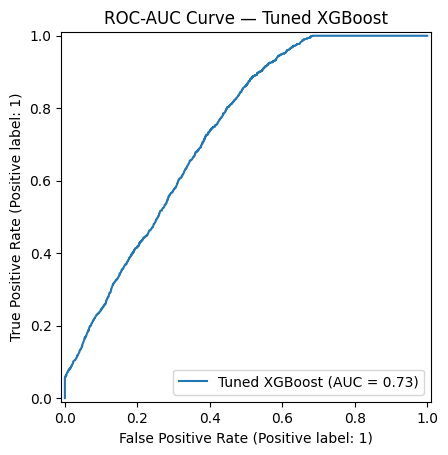

Tuned XGBoost F1 Score: 0.1079
Confusion Matrix:
[[6128    0]
 [1124   68]]


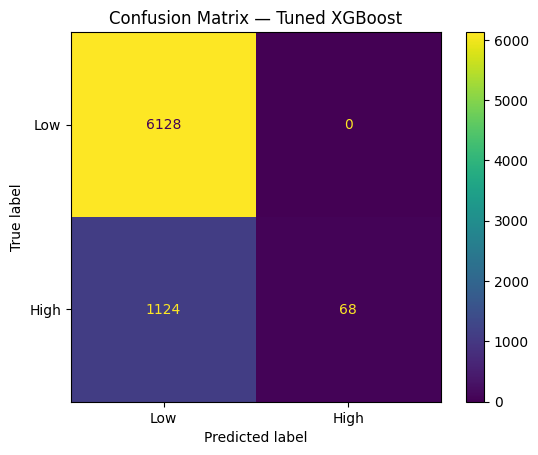

In [63]:
from sklearn.metrics import (
    roc_auc_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)
import matplotlib.pyplot as plt

# Predictions from tuned XGBoost
xgb_pred = best_xgb.predict(X_test)
xgb_proba = best_xgb.predict_proba(X_test)[:, 1]

# -------------------------
# ROC-AUC
# -------------------------
roc_auc = roc_auc_score(y_test, xgb_proba)

print("Tuned XGBoost ROC-AUC:", round(roc_auc, 4))

RocCurveDisplay.from_predictions(
    y_test,
    xgb_proba,
    name="Tuned XGBoost"
)

plt.title("ROC-AUC Curve — Tuned XGBoost")
plt.show()


# -------------------------
# F1 Score
# -------------------------
f1 = f1_score(y_test, xgb_pred)

print("Tuned XGBoost F1 Score:", round(f1, 4))


# -------------------------
# Confusion Matrix
# -------------------------
cm = confusion_matrix(y_test, xgb_pred)

print("Confusion Matrix:")
print(cm)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Low", "High"]
).plot()

plt.title("Confusion Matrix — Tuned XGBoost")
plt.show()